In [104]:
import torch 
import torch.nn as nn 
import torch.optim as optim 
import seaborn as sns 
import matplotlib.pyplot as plt 
import pandas as pd 
import numpy as np 
from torch.utils.data import Dataset , DataLoader

In [94]:
class Dataload(Dataset): 
    def __init__(self,csv_data): 
        data=pd.read_csv(csv_data)
        self.x=data.iloc[:,:-1].values 
        self.y=data.iloc[:,-1].values

        self.x=torch.tensor(self.x,dtype=torch.float32)
        self.y=torch.tensor(self.y,dtype=torch.float32).view(-1,1)



    def __len__(self): 
        return self.y.shape[0]

    def __getitem__(self,ind):
        return self.x[ind],self.y[ind]

In [107]:
batch_size=20
dataset=Dataload("placement.csv")
dataloader=DataLoader(dataset,shuffle=True,batch_size=batch_size)


In [26]:
data=pd.read_csv('placement.csv')
data 

,cgpa,resume_score,placed
0,8.14,6.52,1
1,6.17,5.17,0
2,8.27,8.86,1
3,6.88,7.27,1
4,7.52,7.30,1
...,...,...,...
95,6.33,6.38,0
96,8.23,7.76,1
97,6.65,7.78,0
98,8.14,5.63,1


In [87]:
x=data.iloc[:,:-1].values 
y=data.iloc[:,-1].values
x=torch.tensor(x,dtype=torch.float32)
y=torch.tensor(y,dtype=torch.float32).view(-1,1)


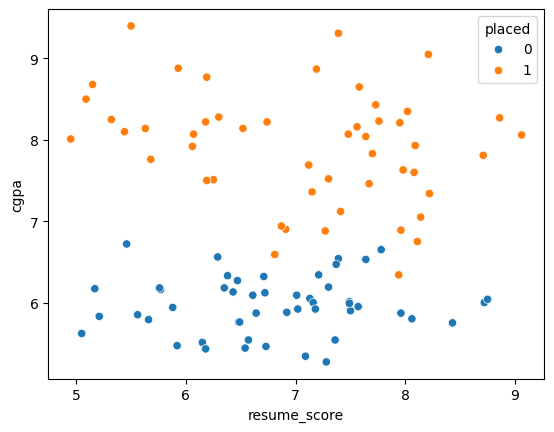

In [72]:
sns.scatterplot(data=data,x='resume_score',y='cgpa',hue='placed')
plt.savefig('data scatter plot.png')

In [29]:
class Perceptron(nn.Module): 
    def __init__(self,input_dim):
        super().__init__()
        self.fc=nn.Linear(input_dim,1)

    def forward(self,x): 
        return torch.sigmoid(self.fc(x)) 
        
    def predict(self, X_np):
        self.eval()
        with torch.no_grad():
            x_t = torch.tensor(X_np, dtype=torch.float32)
            probs = self.forward(x_t)            
            preds = (probs > 0.5).int().squeeze(1) 
        return preds.cpu().numpy()

    

In [30]:
dataset.x.shape

torch.Size([100, 2])

In [31]:
model=Perceptron(input_dim=dataset.x.shape[1])
loss_function=nn.BCELoss()
optimizer=optim.SGD(model.parameters(),lr=0.01)

In [96]:
epochs=200
for epoch in range(epochs):
    for X, Y in dataloader:
        # Forward pass
        outputs = model(X)   # this calls forward()
        loss = loss_function(outputs, Y)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


if (epochs+1)%200==0: 
    print(f'Epoch={epoch+1}/{epochs} , Loss:{loss.item():.4f}')
    

    

In [113]:

for i in range((data.shape[0]//batch_size)+1):
    p[i]=[]
    q[i]=[]
(p1, q1), (p2, q2), (p3, q3), (p4, q4), (p5, q5)=dataloader

IndexError: index 0 is out of bounds for axis 0 with size 0

In [98]:


x=data.iloc[:,:-1].values 
y=data.iloc[:,-1].values
with torch.no_grad():
    # preds = (model(x) > 0.5).float()
    preds=model.predict(data.iloc[:,:-1].values)
    acc = (preds == y).sum()
    percent=((acc/x.shape[0]+0.000001)*100)
    print(f"Accuracy: {percent}%")

Accuracy: 77.0001%


In [62]:
type(preds)

numpy.ndarray

In [64]:
preds.shape

(100,)

In [65]:
type(acc)

numpy.float64

In [50]:
preds 

tensor([[1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
      

In [73]:
print("Weights:", model.fc.weight.data)
print("Bias:", model.fc.bias.data)


Weights: tensor([[ 0.8902, -0.7085]])
Bias: tensor([-1.0626])


In [35]:
x=data.iloc[:,:-1].values 
y=data.iloc[:,-1].values

In [36]:
type(x),type(y)

(numpy.ndarray, numpy.ndarray)

In [37]:
from mlxtend.plotting import plot_decision_regions

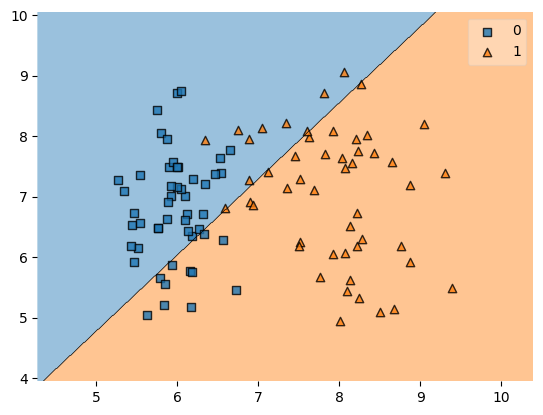

In [71]:
plot_decision_regions(x,y,model)
plt.savefig('Perceptron Decision Boundary.png')

In [74]:
data

,cgpa,resume_score,placed
0,8.14,6.52,1
1,6.17,5.17,0
2,8.27,8.86,1
3,6.88,7.27,1
4,7.52,7.30,1
...,...,...,...
95,6.33,6.38,0
96,8.23,7.76,1
97,6.65,7.78,0
98,8.14,5.63,1


In [77]:
model.predict([[6.09,6.61]])

array([0], dtype=int32)

In [84]:
x1=data.iloc[:,:-1]
x1, type(x1)

(    cgpa  resume_score
 0   8.14          6.52
 1   6.17          5.17
 2   8.27          8.86
 3   6.88          7.27
 4   7.52          7.30
 ..   ...           ...
 95  6.33          6.38
 96  8.23          7.76
 97  6.65          7.78
 98  8.14          5.63
 99  6.09          6.61
 
 [100 rows x 2 columns],
 pandas.core.frame.DataFrame)

In [86]:
x1=torch.tensor(x1.values,dtype=torch.float32)